In [2]:
# libraries
import os
import matplotlib.pyplot as plt
import random
import shutil

In [3]:
# dataset path
DATA_PATH = "../dataset/original"

masked: 1915 images
unmasked: 1918 images


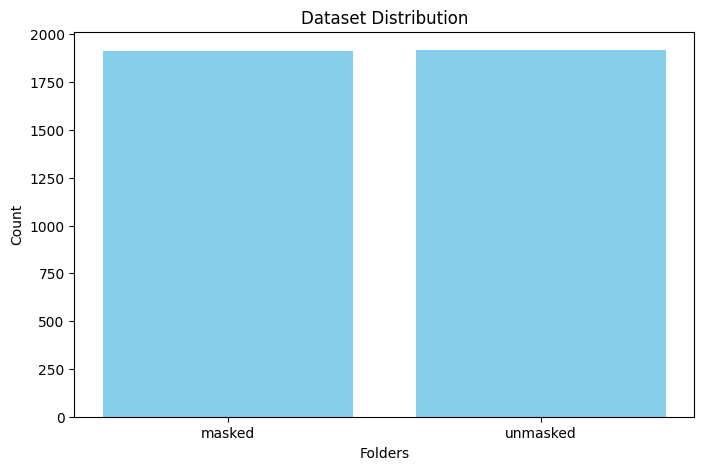

In [4]:
# initial exploration function
def initial_exploration(data_path=DATA_PATH):
    # 1. Automatically get subfolder names from the data_path
    categories = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    counts = []
    
    for category in categories:
        path = os.path.join(data_path, category)
        num_files = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        counts.append(num_files)
        print(f"{category}: {num_files} images")

    # 2. Represent in a graph
    plt.figure(figsize=(8, 5))
    plt.bar(categories, counts, color='skyblue') # Using a neutral color since categories are dynamic
    plt.title('Dataset Distribution')
    plt.xlabel('Folders')
    plt.ylabel('Count')
    plt.show()

initial_exploration()

In [5]:
MAX_IMAGES    = 1500
TRAIN_SPLIT   = 0.7
TEST_SPLIT    = 0.1
VAL_SPLIT     = 0.2
NEW_DATA_PATH = "../dataset/processed"


Processed masked: 1050 Train, 300 Val, 150 Test
Processed unmasked: 1050 Train, 300 Val, 150 Test


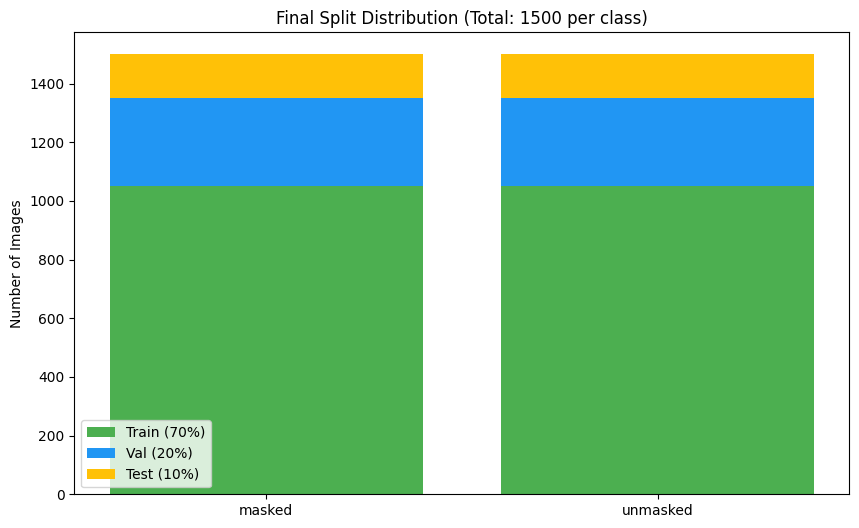

In [6]:
def prepare_data():
    categories = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
    
    # Storage for graphing
    plot_data = {cat: {} for cat in categories}

    for category in categories:
        src_path = os.path.join(DATA_PATH, category)
        all_images = [f for f in os.listdir(src_path) if os.path.isfile(os.path.join(src_path, f))]
        random.shuffle(all_images)
        
        subset = all_images[:MAX_IMAGES]
        
        train_idx = int(MAX_IMAGES * TRAIN_SPLIT)
        val_idx = train_idx + int(MAX_IMAGES * VAL_SPLIT)
        
        data_splits = {
            'train': subset[:train_idx],
            'val': subset[train_idx:val_idx],
            'test': subset[val_idx:]
        }
        
        # Save counts for the graph
        for split, files in data_splits.items():
            plot_data[category][split] = len(files)

        # Create folders and copy files
        for split_name, files in data_splits.items():
            dest_dir = os.path.join(NEW_DATA_PATH, split_name, category)
            os.makedirs(dest_dir, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(src_path, f), os.path.join(dest_dir, f))
                
        print(f"Processed {category}: {len(data_splits['train'])} Train, {len(data_splits['val'])} Val, {len(data_splits['test'])} Test")

    # --- GRAPHING SECTION ---
    labels = list(plot_data.keys())
    train_counts = [plot_data[cat]['train'] for cat in labels]
    val_counts = [plot_data[cat]['val'] for cat in labels]
    test_counts = [plot_data[cat]['test'] for cat in labels]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, train_counts, label='Train (70%)', color='#4CAF50')
    plt.bar(labels, val_counts, bottom=train_counts, label='Val (20%)', color='#2196F3')
    plt.bar(labels, test_counts, bottom=[i+j for i,j in zip(train_counts, val_counts)], label='Test (10%)', color='#FFC107')

    plt.title(f'Final Split Distribution (Total: {MAX_IMAGES} per class)')
    plt.ylabel('Number of Images')
    plt.legend()
    plt.show()

prepare_data()